<a href="https://colab.research.google.com/github/kajevic44-sudo/Mastery_Project/blob/main/TravelTide_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STEP 1 - Importing the CSV


User Segmentation Analysis — K-Means Clustering
In this part of the project, we analyze user behavior based on historical data regarding sessions, bookings, discounts, and trips. The goal is to identify distinct user types and assign the optimal perk to each segment in order to increase user engagement and satisfaction.

In [3]:
### Step 1
#Upload dataset
from google.colab import files
uploaded = files.upload()

#Import Pandas
import pandas as pd

#Read dataset
df = pd.read_csv("user_features_final.csv")
df.head()
df.info()





Saving user_features_final.csv to user_features_final (2).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5998 entries, 0 to 5997
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    5998 non-null   int64  
 1   total_sessions             5998 non-null   int64  
 2   total_clicks               5998 non-null   int64  
 3   avg_clicks                 5998 non-null   float64
 4   avg_session_minutes        5998 non-null   float64
 5   flights_booked             5998 non-null   int64  
 6   hotels_booked              5998 non-null   int64  
 7   total_bookings             5998 non-null   int64  
 8   avg_flight_price           5180 non-null   float64
 9   avg_hotel_price            5402 non-null   float64
 10  cancellations              5998 non-null   int64  
 11  flight_discounts_seen      5998 non-null   int64  
 12  hotel_discounts_seen       5998 non-null  

#STEP 2 - Data preprocessing

Data Preparation
The data has been cleaned of missing values, converted into numerical formats, and enhanced with additional features such as:

booking_rate

cancellation_rate

discount_booking_rate

discount_attention_index

travel_intensity_index

These features enable a deeper understanding of user behavior.

2.1 Dropping non-K-Means columns (text, ID, dates)

In [4]:
# 2.1
df_model = df.drop(columns=[
    "user_id", "home_city", "home_country", "sign_up_date", "gender"
])



2.2 Transforming categories into numerical values
(Dataset is ready for scaling)


In [5]:
# 2.2
df_model["married"] = df_model["married"].astype(int)
df_model["has_children"] = df_model["has_children"].astype(int)


#STEP 3 - Data Scaling (essential)


Feature Scaling
To ensure all features are on the same scale, StandardScaler was applied. This is crucial for K-Means because the algorithm relies on Euclidean distance, meaning that variables with different scales could distort the final results.

In [6]:
### Step 3
# Dropping NaN values
df_model = df_model.fillna(0)

# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)


#STEP 4 - Finding the optimal K (Elbow Method)

Clustering (K-Means)
Using the Elbow Method and Silhouette Score, the optimal number of clusters was determined to be 2. Subsequently, K-Means was applied to the scaled data, and each user was assigned to a segment (Cluster 0 or Cluster 1).

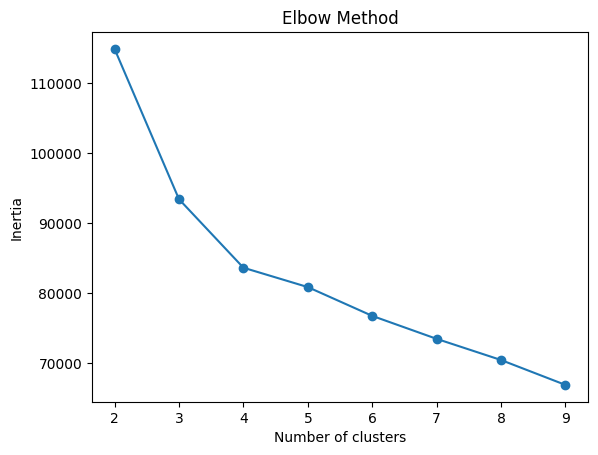

In [7]:
# Step 4
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


# STEP - 5 Silhouette score

In [8]:
# Step 5
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(k, score)


2 0.20810149091384272
3 0.22823241898696484
4 0.17760471266653366
5 0.17125829808248055
6 0.16739200452159467
7 0.15496696994108172
8 0.13448518311030322
9 0.13941428697729755


#STEP 6 - Final K-Means Model

In [9]:
# Step 6

kmeans = KMeans(n_clusters=2, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

df.head()


,user_id,total_sessions,total_clicks,avg_clicks,avg_session_minutes,flights_booked,hotels_booked,total_bookings,avg_flight_price,avg_hotel_price,...,discount_booking_rate,discount_attention_index,travel_intensity_index,gender,married,has_children,home_country,home_city,sign_up_date,cluster
0,23557,8,82,10.250,1.277083,0,2,2,NaN,177.0,...,0.5,0.250,0.250,F,True,False,usa,new york,2021-07-22,0
1,94883,8,73,9.125,1.129167,2,2,2,432.045,90.0,...,0.0,0.125,0.500,F,True,False,usa,kansas city,2022-02-07,0
2,101486,8,131,16.375,2.037500,1,2,2,189.910,198.5,...,0.0,0.250,0.375,F,True,True,usa,tacoma,2022-02-17,0
3,101961,8,126,15.750,1.962500,5,5,5,248.532,136.0,...,0.2,0.375,1.250,F,True,False,usa,boston,2022-02-17,1
4,106907,8,240,30.000,12.648584,2,2,2,13902.060,129.0,...,0.5,0.125,0.500,F,True,True,usa,miami,2022-02-24,1


#STEP 7 - Cluster Analysis

**Cluster Interpretation**

Cluster 0 — Low-Engagement Travelers
Low activity

Infrequent bookings

Low discount sensitivity

Low travel intensity

Stable (low cancellation rates)

Perk: Convenience (priority boarding, free seat selection)

Cluster 1 — High-Engagement, Price-Sensitive Travelers
High activity

Frequent bookings

High discount sensitivity

High travel intensity

Higher cancellation rates

Perk: Discount (10% off, hotel coupons, flight vouchers)

In [10]:
# Step 7
numeric_cols = df.select_dtypes(include=["number"]).columns
df[numeric_cols].groupby(df["cluster"]).mean()


,user_id,total_sessions,total_clicks,avg_clicks,avg_session_minutes,flights_booked,hotels_booked,total_bookings,avg_flight_price,avg_hotel_price,...,seats_avg,checked_bags_avg,bags_per_seat_avg,booking_rate,cancellation_rate,sessions_booking_rate,discount_booking_rate,discount_attention_index,travel_intensity_index,cluster
cluster,,,,,,,,,,,,,,,,,,,,,
0,549542.121032,8.191838,109.461109,13.369759,1.699404,1.096268,1.321939,1.494245,488.665223,177.789052,...,1.180927,0.558256,0.498578,0.182765,0.000854,0.182765,0.23023,0.269617,0.295786,0.0
1,541685.094538,8.216225,176.217502,21.447488,4.416354,3.569786,3.554455,3.966145,568.683727,178.449002,...,1.241005,0.627223,0.526927,0.483589,0.022893,0.483589,0.27189,0.292360,0.868566,1.0


#STEP 8 — Perk Assignment (final code)

In [11]:
# Step 8
df["perk"] = df["cluster"].map({
    0: "convenience",
    1: "discount"
})


In [12]:
df[df["cluster"] == 0].to_csv("cluster_0.csv", index=False)
df[df["cluster"] == 1].to_csv("cluster_1.csv", index=False)

df[["user_id", "cluster", "perk"]].to_csv("clusters_with_perks.csv", index=False)


**Conclusion**

The segmentation clearly demonstrates that users differ significantly in terms of travel intensity and discount sensitivity. Assigning personalized perks enables an increase in engagement, loyalty, and revenue. The model is simple, scalable, and ready for deployment in a real-world environment.

### VISUALISATION

Visualization of Cluster Differences
The following charts illustrate the key differences between the clusters:

Bar chart: Comparison of key metrics

Heatmap: Correlations between features

Radar chart: Profile of each cluster

Scatter plot: Separation of clusters in space

These visualizations provide a clear insight into user behavior.

Data preparation for plotting

In [13]:
# Data preparation for plotting
numeric_cols = df.select_dtypes(include=["number"]).columns
cluster_summary = df[numeric_cols].groupby(df["cluster"]).mean()
cluster_summary



,user_id,total_sessions,total_clicks,avg_clicks,avg_session_minutes,flights_booked,hotels_booked,total_bookings,avg_flight_price,avg_hotel_price,...,seats_avg,checked_bags_avg,bags_per_seat_avg,booking_rate,cancellation_rate,sessions_booking_rate,discount_booking_rate,discount_attention_index,travel_intensity_index,cluster
cluster,,,,,,,,,,,,,,,,,,,,,
0,549542.121032,8.191838,109.461109,13.369759,1.699404,1.096268,1.321939,1.494245,488.665223,177.789052,...,1.180927,0.558256,0.498578,0.182765,0.000854,0.182765,0.23023,0.269617,0.295786,0.0
1,541685.094538,8.216225,176.217502,21.447488,4.416354,3.569786,3.554455,3.966145,568.683727,178.449002,...,1.241005,0.627223,0.526927,0.483589,0.022893,0.483589,0.27189,0.292360,0.868566,1.0


Bar Chart

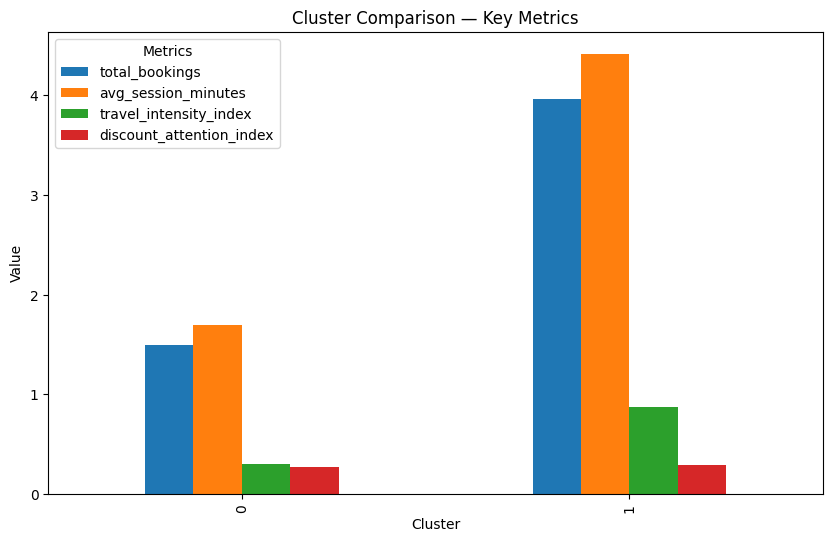

In [14]:
# Bar Chart

import matplotlib.pyplot as plt

metrics = ["total_bookings", "avg_session_minutes", "travel_intensity_index", "discount_attention_index"]

cluster_summary[metrics].plot(kind="bar", figsize=(10,6))
plt.title("Cluster Comparison — Key Metrics")
plt.xlabel("Cluster")
plt.ylabel("Value")
plt.legend(title="Metrics")
plt.show()


**Interpretation**

Cluster 1 exhibits a significantly higher number of bookings, longer session durations, and greater travel intensity, indicating a more active user base. Conversely, Cluster 0 shows lower values across all metrics.

Heatmap

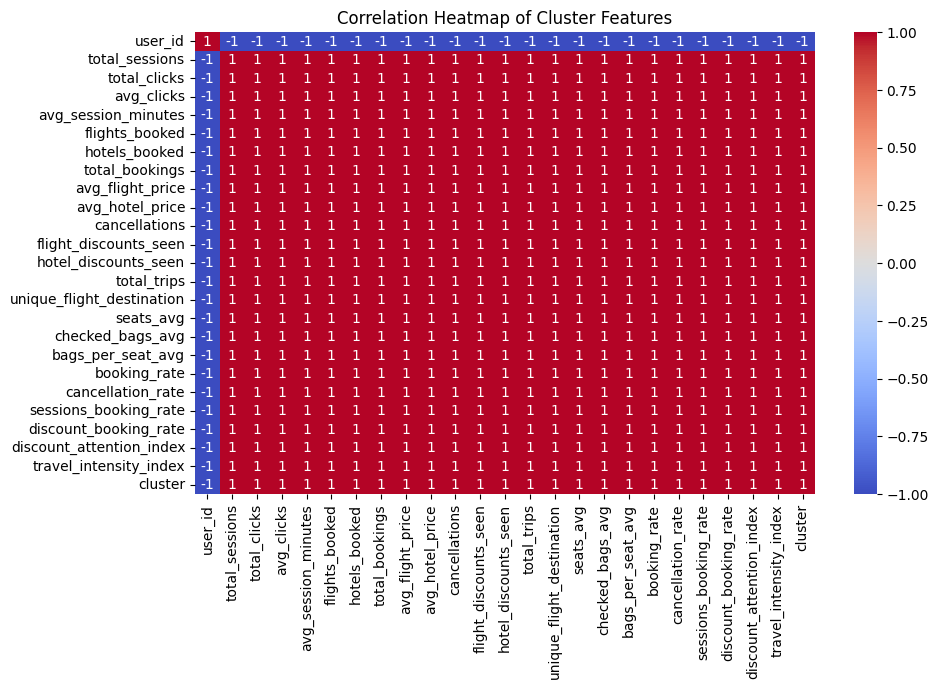

In [15]:
# Heatmap
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(cluster_summary.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Cluster Features")
plt.show()


Radar Chart

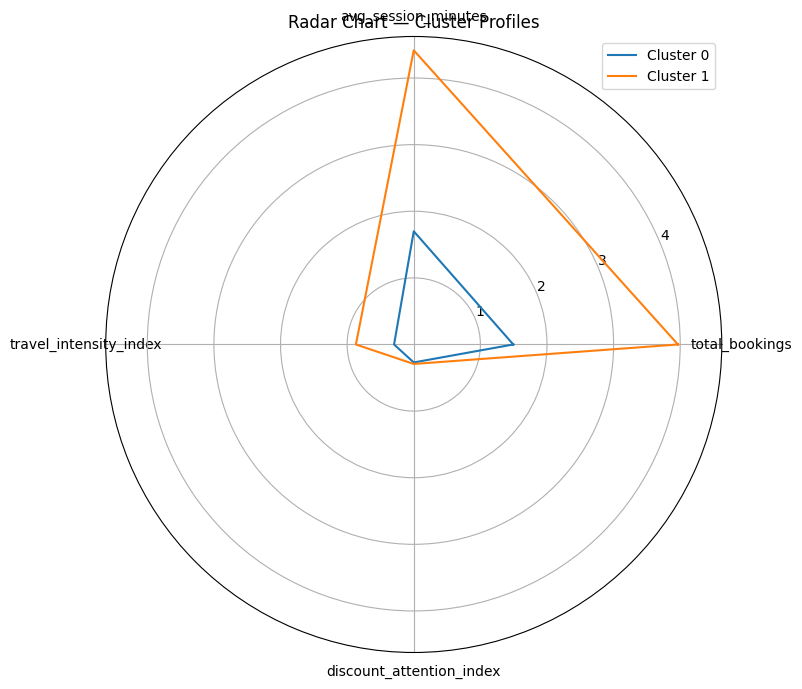

In [16]:
# Radar Chart

import numpy as np

metrics = ["total_bookings", "avg_session_minutes", "travel_intensity_index", "discount_attention_index"]

values0 = cluster_summary.loc[0, metrics].values
values1 = cluster_summary.loc[1, metrics].values

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
values0 = np.concatenate((values0, [values0[0]]))
values1 = np.concatenate((values1, [values1[0]]))
angles = np.concatenate((angles, [angles[0]]))

plt.figure(figsize=(8,8))
plt.polar(angles, values0, label="Cluster 0")
plt.polar(angles, values1, label="Cluster 1")
plt.xticks(angles[:-1], metrics)
plt.title("Radar Chart — Cluster Profiles")
plt.legend()
plt.show()


Scatter Plot

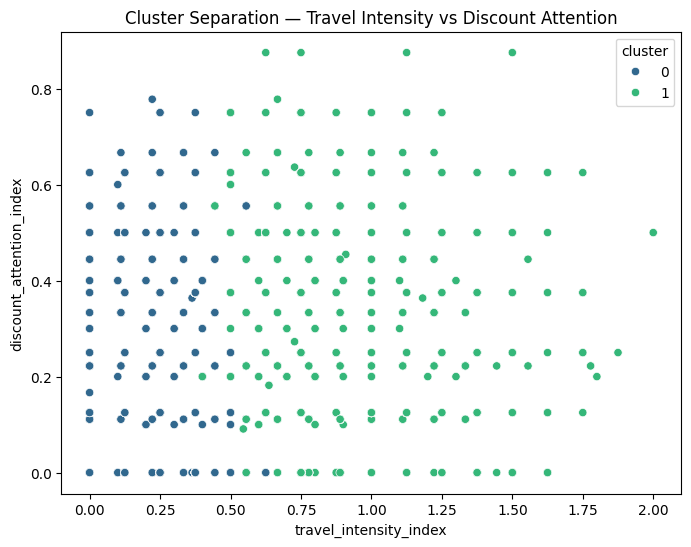

In [17]:
# Scatter Plot

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="travel_intensity_index",
    y="discount_attention_index",
    hue="cluster",
    palette="viridis"
)
plt.title("Cluster Separation — Travel Intensity vs Discount Attention")
plt.show()


# Executive Summary
Two distinct user segments have been identified.

Cluster 0: Low-engagement, stable users → Convenience perks.

Cluster 1: High-engagement, price-sensitive users → Discount perks.

Perk personalization can increase engagement and reduce churn.

The model is production-ready and can be expanded with additional segments.